In [30]:
#libraries
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [22]:
# 1 setup

grid_h = 4
grid_w = 12
grid = np.zeros((grid_h, grid_w))
grid[:,:] = -1 #all other spaces
#grid[-1, 0] = 0 #start
grid[-1, 1:-1] = -100 #cliff
grid[-1, -1] = 1 # goal
epsilon = 0.1
alpha = 0.5 # step size
gamma = 1 # gamma for Q-Learning and Expected Sarsa
a_up, a_down, a_left, a_right = np.array([-1, 0]), np.array([1, 0]), np.array([0, -1]), np.array([0, 1])
actions = [a_up, a_down, a_left, a_right]
s_start = np.array([3, 0])
s_goal = np.array([3, 11])

In [23]:
# 2 helper functions

def step(state, action):
    next_state = state + action
    if (
        next_state[0] < 0 or next_state[0] >= grid_h or
        next_state[1] < 0 or next_state[1] >= grid_w
    ):
        next_state = state.copy()
    reward = grid[next_state[0], next_state[1]]
    if reward == -100:
        next_state = s_start.copy()
    return next_state, reward

print(step(state=np.array([3, 0]), action=a_right)) # ([3, 0], -100)
print(step(state=np.array([3, 0]), action=a_up))    # ([2, 0], -1)
print(step(state=np.array([3, 0]), action=a_down))  # ([3, 0], -1)

def choose_action(state, q_values):
    row, col = state
    if np.random.rand() < epsilon:
        action = np.random.randint(len(actions))
    else:
        q_row = q_values[row, col]
        best_actions = np.flatnonzero(q_row == np.max(q_row))
        action = np.random.choice(best_actions)
    return action

q_values = np.zeros((grid_h, grid_w, 4))
action = choose_action(state=[3, 0], q_values=q_values)
print(action)


(array([3, 0]), -100.0)
(array([2, 0]), -1.0)
(array([3, 0]), -1.0)
1


In [24]:
# 3 SARSA

def sarsa(q_values, alpha=alpha):
    state = s_start.copy()
    action = choose_action(state, q_values)
    rewards = 0.0

    while not np.array_equal(state, s_goal):
        next_state, reward = step(state, actions[action])
        rewards += reward

        if np.array_equal(next_state, s_goal):
            td_target = reward
            q_values[state[0], state[1], action] += alpha * (
                td_target - q_values[state[0], state[1], action]
            )
            break

        next_action = choose_action(next_state, q_values)
        td_target = reward + gamma * q_values[next_state[0], next_state[1], next_action]
        td_error = td_target - q_values[state[0], state[1], action]
        q_values[state[0], state[1], action] += alpha * td_error

        state = next_state
        action = next_action

    return rewards  # one episode

q_values = np.zeros((grid_h, grid_w, 4))
rewards = sarsa(q_values, alpha=alpha)
print(rewards)

-1823.0


In [25]:
# 4 Q-Learning

def qlearning(q_values, alpha=alpha):
    state = s_start.copy()
    rewards = 0.0

    while not np.array_equal(state, s_goal):
        action = choose_action(state, q_values)
        next_state, reward = step(state, actions[action])
        rewards += reward

        if np.array_equal(next_state, s_goal):
            td_target = reward
        else:
            td_target = reward + gamma * np.max(q_values[next_state[0], next_state[1]])

        td_error = td_target - q_values[state[0], state[1], action]
        q_values[state[0], state[1], action] += alpha * td_error

        state = next_state

    return rewards  # one episode

q_values = np.zeros((grid_h, grid_w, 4))
rewards = qlearning(q_values, alpha=alpha)
print(rewards)


-1353.0


In [27]:
# 5 Expected SARSA

def expected_sarsa(q_values, alpha=alpha):
    state = s_start.copy()
    rewards = 0.0

    while not np.array_equal(state, s_goal):
        action = choose_action(state, q_values)
        next_state, reward = step(state, actions[action])
        rewards += reward

        if np.array_equal(next_state, s_goal):
            td_target = reward
        else:
            next_q = q_values[next_state[0], next_state[1]]
            best_actions = np.flatnonzero(next_q == np.max(next_q))
            policy = np.ones(len(actions)) * (epsilon / len(actions))
            policy[best_actions] += (1 - epsilon) / len(best_actions)
            expected_q = np.sum(policy * next_q)
            td_target = reward + gamma * expected_q

        td_error = td_target - q_values[state[0], state[1], action]
        q_values[state[0], state[1], action] += alpha * td_error

        state = next_state

    return rewards  # one episode

q_values = np.zeros((grid_h, grid_w, 4))
rewards = expected_sarsa(q_values, alpha=alpha)
print(rewards)


-866.0


In [28]:
# 6 Code Run

num_episodes = 500
num_runs = 50
q_sarsa_runs = np.zeros((grid_h, grid_w, 4))
q_qlearning_runs = np.zeros((grid_h, grid_w, 4))
q_expected_sarsa_runs = np.zeros((grid_h, grid_w, 4))

rewards_per_episode_sarsa = np.zeros(num_episodes)
rewards_per_episode_qlearning = np.zeros(num_episodes)
rewards_per_episode_expected_sarsa = np.zeros(num_episodes)

for run in tqdm(range(num_runs)):
    q_sarsa = np.zeros((grid_h, grid_w, 4))
    q_qlearning = np.zeros((grid_h, grid_w, 4))
    q_expected_sarsa = np.zeros((grid_h, grid_w, 4))

    for episode in range(num_episodes):
        rewards_per_episode_sarsa[episode] += sarsa(q_sarsa)
        rewards_per_episode_qlearning[episode] += qlearning(q_qlearning)
        rewards_per_episode_expected_sarsa[episode] += expected_sarsa(q_expected_sarsa)

    q_sarsa_runs += q_sarsa
    q_qlearning_runs += q_qlearning
    q_expected_sarsa_runs += q_expected_sarsa

# average over runs
rewards_per_episode_sarsa /= num_runs
rewards_per_episode_qlearning /= num_runs
rewards_per_episode_expected_sarsa /= num_runs
q_sarsa_runs_avg = q_sarsa_runs / num_runs
q_qlearning_runs_avg = q_qlearning_runs / num_runs
q_expected_sarsa_runs_avg = q_expected_sarsa_runs / num_runs


100%|██████████| 50/50 [01:40<00:00,  2.01s/it]


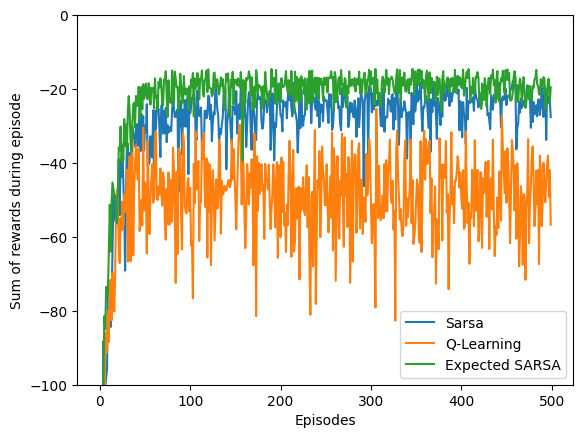

In [31]:
# 7 Plot

plt.plot(rewards_per_episode_sarsa, label='Sarsa')
plt.plot(rewards_per_episode_qlearning, label='Q-Learning')
plt.plot(rewards_per_episode_expected_sarsa, label='Expected SARSA')
plt.xlabel('Episodes')
plt.ylabel('Sum of rewards during episode')
plt.ylim([-100, 0])
plt.legend()
plt.show()

In [32]:
# 8 Optimal Policy

def print_optimal_policy(q_value):
    optimal_policy = np.empty((grid_h, grid_w), dtype=str)
    arrows = ['U', 'D', 'L', 'R']

    for i in range(grid_h):
        for j in range(grid_w):
            if np.array_equal(np.array([i, j]), s_goal):
                optimal_policy[i, j] = 'G'
            else:
                best_action = np.argmax(q_value[i, j])
                optimal_policy[i, j] = arrows[best_action]

    for row in optimal_policy:
        print(row)

print('SARSA policy:')
print_optimal_policy(q_sarsa_runs_avg)
print('Q-Learning policy:')
print_optimal_policy(q_qlearning_runs_avg)
print('Expected SARSA policy:')
print_optimal_policy(q_expected_sarsa_runs_avg)

SARSA policy:
['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'D']
['U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'R' 'D']
['U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'R' 'D']
['U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'G']
Q-Learning policy:
['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'D' 'D' 'D']
['R' 'R' 'R' 'R' 'R' 'R' 'D' 'R' 'R' 'D' 'D' 'D']
['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'D']
['U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'G']
Expected SARSA policy:
['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'D']
['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'D']
['U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'R' 'R' 'D']
['U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'G']
